# Section 6 replication — two-asset example, closed form vs exact HJB

Replicates the numerical study of Section 6 of *Closed-form approximations in multi-asset
market making* using the repo's Section-5 machinery: $d=2$ with correlation, price drifts,
**logistic intensities** $\Lambda(\delta)=\lambda_{RFQ}/(1+e^{\alpha_\Lambda+\beta_\Lambda\delta})$,
and a discretized Gamma size distribution.

| Parameter | Value |
|---|---|
| $\mu$ | $(+0.1, -0.1)$ €/day |
| $\sigma$ | $(1.2, 0.6)$ €/day$^{1/2}$, $\rho=0.5$ |
| Objective | Model B, $\gamma = 8\cdot 10^{-6}$ €$^{-1}$, $T=7$d |
| Intensity | $\lambda_{RFQ}=30$/day, $\alpha_\Lambda=0.7$, $\beta_\Lambda=30$ €$^{-1}$ (both assets, both sides) |
| Sizes $\nu$ | $\{6250, 12500, 18750, 25000\}$ w.p. $\{0.534, 0.350, 0.097, 0.019\}$ (mean $\approx 10{,}000$) |
| Risk limits | $Q^1 = 75{,}000$, $Q^2=300{,}000$; grid step 6250 → $25\times 97$ inventory grid |

Benchmark: finite-difference solve of the exact HJ equation (true logistic Hamiltonians, same
size mixture, drift, correlation, limits). Comparison: value-function shape, per-size quote
slices (the paper's Figures 1–11 program), plus quantitative error metrics and behavioral
sign checks the paper reports only qualitatively.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from mmquote import (LogisticIntensity, ModelConfig, SizeDistribution,
                     build_multi_asset_engine, solve_fd_hjb)
from mmquote.hamiltonian import HamiltonianSide

plt.rcParams.update({"figure.figsize": (10, 3.4), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
RESULTS = {}
def record(name, passed, detail=""):
    RESULTS[name] = passed
    print(f"[{'PASS' if passed else 'FAIL'}] {name}" + (f"  --  {detail}" if detail else ""))

# ---- Section 6 specification ----
lam = LogisticIntensity(lam_rfq=30.0, alpha=0.7, beta=30.0)
Sigma = np.array([[1.44, 0.36], [0.36, 0.36]])
mu = np.array([0.1, -0.1])
GAMMA, T = 8e-6, 7.0
sd = SizeDistribution(sizes=np.array([6250., 12500., 18750., 25000.]),
                      probs=np.array([0.534, 0.350, 0.097, 0.019]))
QLIM, STEP = [75_000.0, 300_000.0], 6250.0
SIZE_NAMES = ["very small", "small", "large", "very large"]

cfg = ModelConfig(gamma=GAMMA, z=sd.m1, T=T, xi=0.0, ergodic=True, n_steps=2000)
engines = build_multi_asset_engine([lam, lam], [lam, lam], Sigma, cfg,
                                   size_dists=[sd, sd], mu=mu, Q_limits=QLIM)
SOL = engines[0].solution
A_E, B_E = SOL.A_erg, SOL.B_erg
HAM = engines[0].ham_b     # same intensity everywhere; use for delta_star
print("Gamma matrix:\n", SOL.Gamma)
print("A_erg:\n", A_E)
print("B_erg:", B_E, "(drift carrier: mu=+0.1 -> B1<0, mu=-0.1 -> B2>0)")
print(f"finite-T check at T=7: |A(0)-A_erg| = {np.abs(SOL.A_path[0]-A_E).max():.2e}, "
      f"|B(0)-B_erg| = {np.abs(SOL.B_path[0]-B_E).max():.2e}")

Gamma matrix:
 [[0.00087612 0.00015284]
 [0.00015284 0.00041758]]
A_erg:
 [[1.23901386e-06 2.16155422e-07]
 [2.16155422e-07 5.90547595e-07]]
B_erg: [-0.03234376  0.05834322] (drift carrier: mu=+0.1 -> B1<0, mu=-0.1 -> B2>0)
finite-T check at T=7: |A(0)-A_erg| = 7.82e-15, |B(0)-B_erg| = 1.24e-09


## Closed-form quotes on the grid

Per-size proxy quotes (Section 5.4): $\check\delta^{i,b}(q,z) = \tilde\delta^{i,b*}\!\big(2q^\top A e_i + z\,e_i^\top A e_i + e_i^\top B\big)$
with $\tilde\delta^*$ the logistic quote map (Thm 4). Vectorized directly from $(A_{\mathrm{erg}}, B_{\mathrm{erg}})$.

In [2]:
def cf_quote_grid(q1, q2, asset, size, side):
    """Closed-form quote on a meshgrid of inventories."""
    Q1, Q2 = np.meshgrid(q1, q2, indexing="ij")
    Aq_i = A_E[asset, 0] * Q1 + A_E[asset, 1] * Q2
    if side == "b":
        p = 2 * Aq_i + size * A_E[asset, asset] + B_E[asset]
    else:
        p = -2 * Aq_i + size * A_E[asset, asset] - B_E[asset]
    return np.asarray(HAM.delta_star(p))

q1_grid = np.arange(-12, 13) * STEP           # 25 pts
q2_grid = np.arange(-48, 49) * STEP           # 97 pts
print("closed-form quote at q=0, very small, asset 1 (bid, ask):",
      cf_quote_grid([0.],[0.],0,6250.,"b").item(), cf_quote_grid([0.],[0.],0,6250.,"a").item())

closed-form quote at q=0, very small, asset 1 (bid, ask): 0.018294653957718298 0.0751573735138427


## Exact benchmark: finite-difference HJ solve

Backward Euler on the $25\times 97$ grid, $dt=10^{-3}$ day, true logistic Hamiltonians via the
semi-closed $x(p)$ solver, size mixture, drift, correlation, and risk-limit indicators.

In [3]:
t0 = time.time()
FD = solve_fd_hjb([HAM, HAM], [HAM, HAM], Sigma, gamma=GAMMA, T=T,
                  size_dists=[sd, sd], Q_limits=QLIM, base_steps=[STEP, STEP],
                  mu=mu, dt=1e-3, n_snaps=140)
print(f"FD solve: {time.time()-t0:.0f}s, grid {FD.theta0.shape}, {len(FD.t_snaps)} snapshots")

FD solve: 54s, grid (25, 97), 141 snapshots


## Figure-1 replication — convergence to stationary quotes

Optimal bid quotes (very small trades) as a function of time for several inventories. The
paper's point: at $T=7$d the asymptotic regime is clearly reached well before $t=0$; hence
only $t=0$ (equivalently ergodic) quotes are studied thereafter. Dashed lines: closed-form
ergodic quotes at the same inventories.

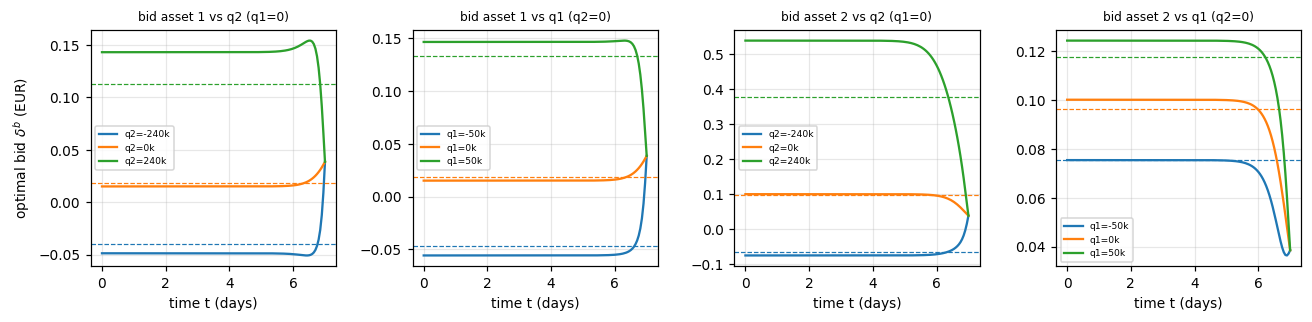

[PASS] Fig 1: stationary regime reached at T=7  --  quote variation over t in [0,4] below half a cent at all shown inventories


In [4]:
z0 = 6250.0
i1_0 = 12; i2_0 = 48                            # grid indices of q=0
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
panels = [(0, "q2", [-240_000, 0, 240_000], "bid asset 1 vs q2 (q1=0)"),
          (0, "q1", [-50_000, 0, 50_000],   "bid asset 1 vs q1 (q2=0)"),
          (1, "q2", [-240_000, 0, 240_000], "bid asset 2 vs q2 (q1=0)"),
          (1, "q1", [-50_000, 0, 50_000],   "bid asset 2 vs q1 (q2=0)")]
stationary_ok = True
for ax, (asset, axis_name, q_vals, title) in zip(axes, panels):
    for qv in q_vals:
        traj = []
        for th in FD.theta_snaps:
            d_b, _, ok_b, _ = FD.quotes(th, asset=asset, size=z0)
            if axis_name == "q1":
                idx = (i1_0 + int(qv/STEP), i2_0)
            else:
                idx = (i1_0, i2_0 + int(qv/STEP))
            traj.append(d_b[idx])
        traj = np.array(traj)
        order = np.argsort(FD.t_snaps)
        ax.plot(FD.t_snaps[order], traj[order], label=f"{axis_name}={qv/1000:.0f}k")
        # closed-form ergodic reference
        q1v = qv if axis_name == "q1" else 0.0
        q2v = qv if axis_name == "q2" else 0.0
        cf = cf_quote_grid([q1v], [q2v], asset, z0, "b").item()
        ax.axhline(cf, ls="--", lw=0.8, color=ax.lines[-1].get_color())
        # stationarity: variation over t in [0, 4] small
        early = traj[order][FD.t_snaps[order] <= 4.0]
        stationary_ok &= (np.ptp(early) < 0.005)
    ax.set_xlabel("time t (days)"); ax.set_title(title, fontsize=8); ax.legend(fontsize=6)
axes[0].set_ylabel(r"optimal bid $\delta^b$ (EUR)")
plt.tight_layout(); plt.show()
record("Fig 1: stationary regime reached at T=7", stationary_ok,
       "quote variation over t in [0,4] below half a cent at all shown inventories")

## Figures 2 & 5 — value function: exact vs closed form

$\theta$ (FD) vs $\check\theta(q) = -q^\top A q - q^\top B$ (level-aligned at $q=0$: the closed-form
$C(t)$ is a $q$-independent level that never enters quotes, so shape is the meaningful object —
the paper makes the same observation about level differences).

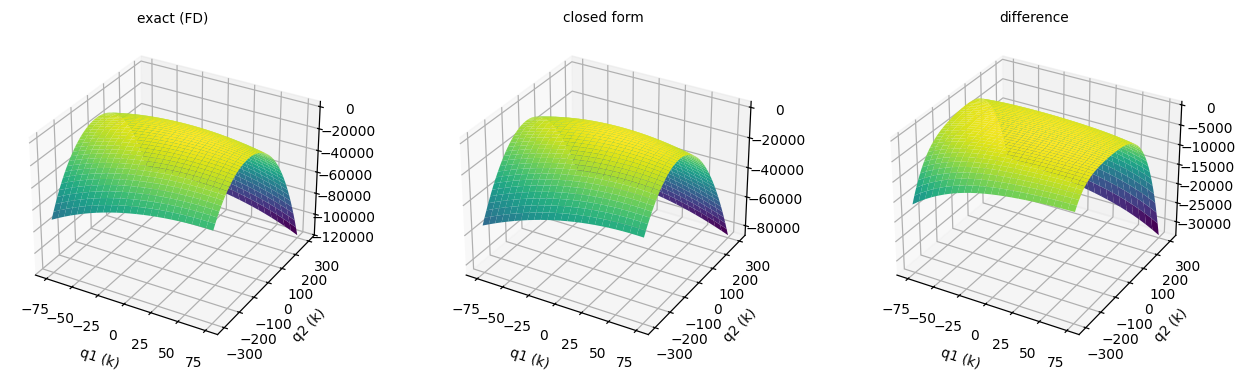

[PASS] Figs 2/5: value-function shape agreement  --  shape correlation = 0.99795; max |diff| = 27.4% of FD range


In [5]:
Q1m, Q2m = np.meshgrid(FD.q_grids[0], FD.q_grids[1], indexing="ij")
theta_fd = FD.theta0 - FD.theta0[i1_0, i2_0]
theta_cf = -(A_E[0,0]*Q1m**2 + 2*A_E[0,1]*Q1m*Q2m + A_E[1,1]*Q2m**2) - (B_E[0]*Q1m + B_E[1]*Q2m)

fig = plt.figure(figsize=(12, 3.4))
for k, (Z, name) in enumerate([(theta_fd, "exact (FD)"), (theta_cf, "closed form"),
                               (theta_fd - theta_cf, "difference")]):
    ax = fig.add_subplot(1, 3, k+1, projection="3d")
    ax.plot_surface(Q1m/1e3, Q2m/1e3, Z, cmap="viridis", linewidth=0)
    ax.set_xlabel("q1 (k)"); ax.set_ylabel("q2 (k)"); ax.set_title(name, fontsize=9)
plt.tight_layout(); plt.show()

cc = np.corrcoef((theta_fd - theta_fd.mean()).ravel(), (theta_cf - theta_cf.mean()).ravel())[0,1]
rel = np.abs(theta_fd - theta_cf).max() / np.ptp(theta_fd)
record("Figs 2/5: value-function shape agreement", cc > 0.99,
       f"shape correlation = {cc:.5f}; max |diff| = {rel:.1%} of FD range")

## Figures 8–11 — per-size quote slices, exact vs closed form

The paper's central comparison: bid quotes for each of the four sizes along the $q^1$ axis
($q^2=0$) and along the $q^2$ axis ($q^1=0$), for both assets. Solid: FD optimal. Dashed:
closed-form approximation. Plus the error metrics the paper leaves qualitative.

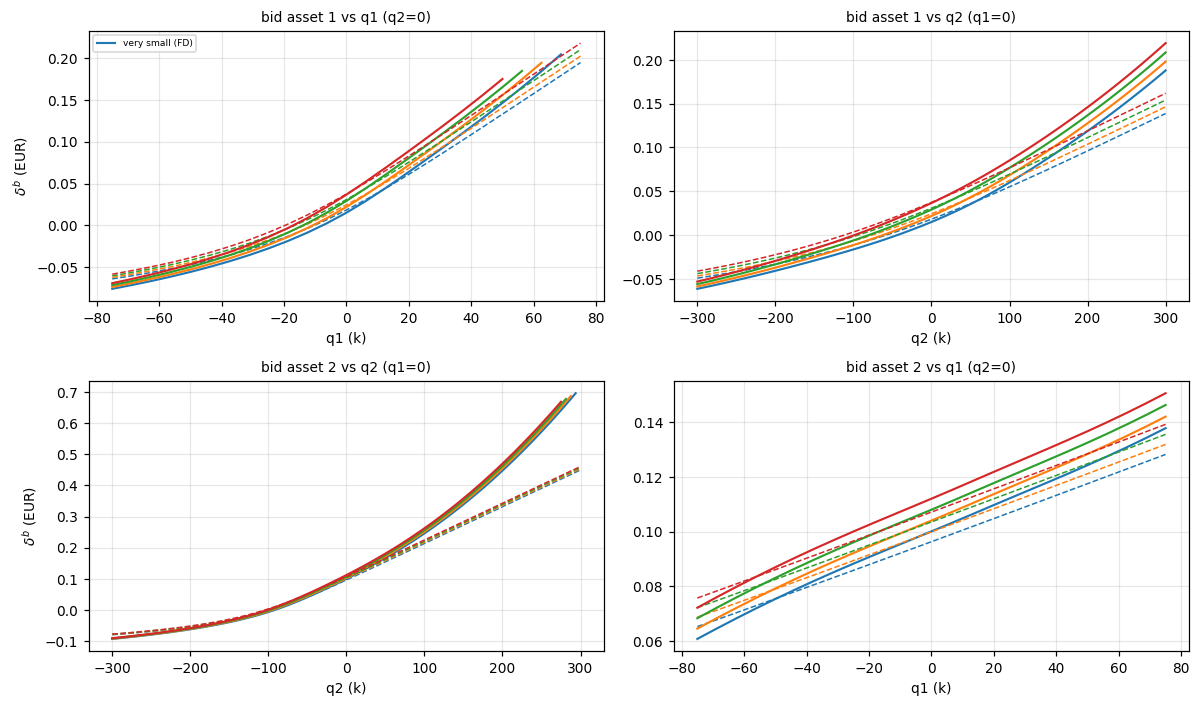

slice                                        size   median inner |err|    max |err|
bid asset 1 vs q1 (q2=0)               very small               0.48c        2.53c
bid asset 1 vs q1 (q2=0)                    small               0.50c        2.29c
bid asset 1 vs q1 (q2=0)                    large               0.45c        2.08c
bid asset 1 vs q1 (q2=0)               very large               0.42c        1.90c
bid asset 1 vs q2 (q1=0)               very small               0.44c        4.92c
bid asset 1 vs q2 (q1=0)                    small               0.42c        5.16c
bid asset 1 vs q2 (q1=0)                    large               0.39c        5.42c
bid asset 1 vs q2 (q1=0)               very large               0.37c        5.72c
bid asset 2 vs q2 (q1=0)               very small               0.44c       25.37c
bid asset 2 vs q2 (q1=0)                    small               0.43c       24.82c
bid asset 2 vs q2 (q1=0)                    large               0.43c       24.27c
bid

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
metrics = {}
slice_specs = [(0, "q1", "bid asset 1 vs q1 (q2=0)"), (0, "q2", "bid asset 1 vs q2 (q1=0)"),
               (1, "q2", "bid asset 2 vs q2 (q1=0)"), (1, "q1", "bid asset 2 vs q1 (q2=0)")]
for ax, (asset, axis_name, title) in zip(axes.ravel(), slice_specs):
    for k, (zk, name) in enumerate(zip(sd.sizes, SIZE_NAMES)):
        d_b, _, ok_b, _ = FD.quotes(FD.theta0, asset=asset, size=zk)
        if axis_name == "q1":
            xs = FD.q_grids[0]; fd_q = d_b[:, i2_0]; ok = ok_b[:, i2_0]
            cf_q = cf_quote_grid(xs, [0.0], asset, zk, "b")[:, 0]
        else:
            xs = FD.q_grids[1]; fd_q = d_b[i1_0, :]; ok = ok_b[i1_0, :]
            cf_q = cf_quote_grid([0.0], xs, asset, zk, "b")[0, :]
        c = f"C{k}"
        ax.plot(xs[ok]/1e3, fd_q[ok], c, lw=1.4, label=f"{name} (FD)" if asset+k==0 else None)
        ax.plot(xs/1e3, cf_q, c+"--", lw=1.0)
        err = np.abs(fd_q[ok] - cf_q[ok])
        n = ok.sum(); inner = err[n//4: 3*n//4]
        metrics[(title, name)] = (float(np.median(inner)), float(err.max()))
    ax.set_title(title, fontsize=9); ax.set_xlabel(axis_name + " (k)")
axes[0,0].set_ylabel(r"$\delta^b$ (EUR)"); axes[1,0].set_ylabel(r"$\delta^b$ (EUR)")
axes[0,0].legend(fontsize=6)
plt.tight_layout(); plt.show()

print(f"{'slice':38s} {'size':>10s} {'median inner |err|':>20s} {'max |err|':>12s}")
worst_inner = 0.0
for (title, name), (med, mx) in metrics.items():
    print(f"{title:38s} {name:>10s} {med*100:>18.2f}c {mx*100:>11.2f}c")
    worst_inner = max(worst_inner, med)
record("Figs 8-11: quote agreement in the inner inventory band", worst_inner < 0.01,
       f"worst median inner-band error = {worst_inner*100:.2f} cents")

## Behavioral checks (signs the paper discusses qualitatively)

1. **Drift tilt**: $\mu^1 > 0$ ⇒ tighter bid / wider ask on asset 1 (accumulate the
   positively-drifting asset); mirrored for asset 2.
2. **Cross-asset skew** ($\rho > 0$): being long asset 2 must widen the bid of asset 1
   ($\partial \delta^{1,b}/\partial q^2 > 0$), in both FD and closed form.
3. **Size monotonicity**: quotes widen with request size (the $\tfrac12\sqrt\gamma z\, e_i^\top\Gamma e_i$ term).

In [7]:
# 1. drift tilt at q=0 (very small size)
tilt_ok = True
for asset, sign in [(0, +1), (1, -1)]:
    d_b, d_a, _, _ = FD.quotes(FD.theta0, asset=asset, size=6250.)
    tilt_fd = d_a[i1_0, i2_0] - d_b[i1_0, i2_0]          # >0 iff bid tighter than ask
    tilt_cf = (cf_quote_grid([0.],[0.],asset,6250.,"a").item()
               - cf_quote_grid([0.],[0.],asset,6250.,"b").item())
    tilt_ok &= (np.sign(tilt_fd) == sign) and (np.sign(tilt_cf) == sign)
record("drift tilt: buy the +drift asset, shed the -drift asset", tilt_ok)

# 2. cross-asset skew sign
d_b, _, ok_b, _ = FD.quotes(FD.theta0, asset=0, size=6250.)
fd_slope = np.polyfit(FD.q_grids[1][ok_b[i1_0,:]], d_b[i1_0, ok_b[i1_0,:]], 1)[0]
cf_slope = 2 * A_E[0, 1]
record("cross-asset skew: d(delta^1b)/dq2 > 0 under rho>0",
       fd_slope > 0 and cf_slope > 0,
       f"FD slope = {fd_slope:.3e}, closed-form slope 2*A_12 = {cf_slope:.3e}")

# 3. size monotonicity in both FD and closed form
d_small = FD.quotes(FD.theta0, 0, 6250.)[0][i1_0, i2_0]
d_big = FD.quotes(FD.theta0, 0, 25000.)[0][i1_0, i2_0]
cf_small = cf_quote_grid([0.],[0.],0,6250.,"b").item(); cf_big = cf_quote_grid([0.],[0.],0,25000.,"b").item()
record("size monotonicity: bigger requests get wider quotes",
       d_big > d_small and cf_big > cf_small,
       f"FD {d_small*100:.2f}c -> {d_big*100:.2f}c; CF {cf_small*100:.2f}c -> {cf_big*100:.2f}c")

[PASS] drift tilt: buy the +drift asset, shed the -drift asset
[PASS] cross-asset skew: d(delta^1b)/dq2 > 0 under rho>0  --  FD slope = 4.028e-07, closed-form slope 2*A_12 = 4.323e-07
[PASS] size monotonicity: bigger requests get wider quotes  --  FD 1.51c -> 3.67c; CF 1.83c -> 3.74c


## Summary

In [8]:
print(f"{'CHECK':62s} RESULT")
print("-" * 70)
for name, passed in RESULTS.items():
    print(f"{name:62s} {'PASS' if passed else 'FAIL'}")
n = sum(RESULTS.values())
print("-" * 70)
print(f"{n}/{len(RESULTS)} Section-6 replication checks passed")
assert n == len(RESULTS)

CHECK                                                          RESULT
----------------------------------------------------------------------
Fig 1: stationary regime reached at T=7                        PASS
Figs 2/5: value-function shape agreement                       PASS
Figs 8-11: quote agreement in the inner inventory band         PASS
drift tilt: buy the +drift asset, shed the -drift asset        PASS
cross-asset skew: d(delta^1b)/dq2 > 0 under rho>0              PASS
size monotonicity: bigger requests get wider quotes            PASS
----------------------------------------------------------------------
6/6 Section-6 replication checks passed
